Create Model 1 using Tensorflow

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
import PIL

from tensorflow import keras
from tensorflow.keras import layers

datasetPath = kagglehub.dataset_download("ongshujian/real-and-fake-pokemon-cards")

def build_tensor_deep_model(hp):
    base_filters = hp.Choice("base_filter", [16, 32]) # for feature extraction
    dense_units = hp.Choice("dense_units", [64, 128]) # for feature classification 
    activeFunctions = hp.Choice("activation", ["relu", "sigmoid", "tanh", "elu"]) # activation function.
    model = keras.models.Sequential([
        layers.Conv2D(base_filters, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 2, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 4, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(dense_units, activation=activeFunctions),
        layers.Dense(2)
    ])
    model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    return model



100%|██████████| 11.0M/11.0M [00:00<00:00, 22.7MB/s]

Extracting files...


Process the data and produce the class distribution plots for training set.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.8 MB/s eta 0:00:00


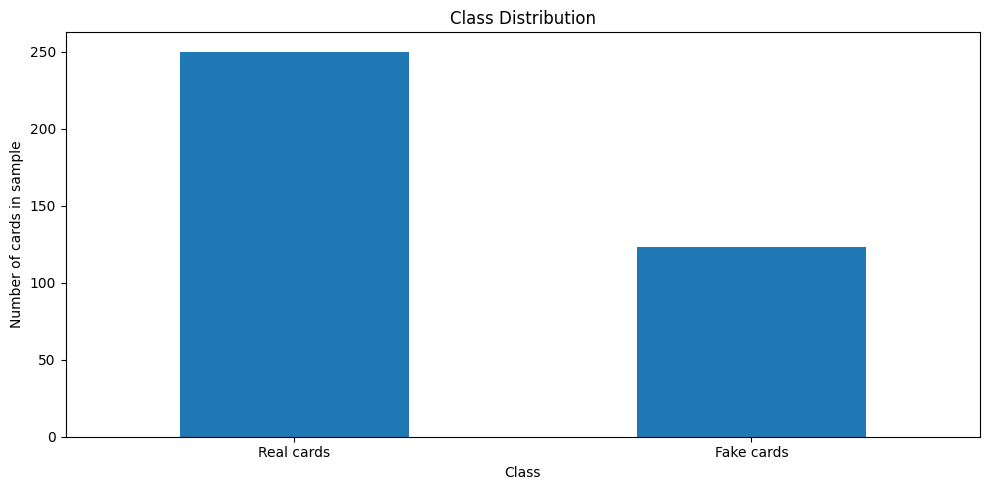

In [ ]:
#install keras tuner so we can tune hypermodels in Tensorflow
%pip install -q -U keras-tuner

import os
#we'll use this tool for training validation split for relative ease of use
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import keras_tuner as kt

df = pd.read_csv(f"{datasetPath}/train_labels.csv") 

#class distribution plot for training set

plt.figure(figsize=(10,5))
df["label"].map({0: "Fake cards", 1: "Real cards"}).value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of cards in sample")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

We're going to do some EDA here. Going to validate and check if images are corrupted

   id  label                                               path
0   1      0  /root/.cache/kagglehub/datasets/ongshujian/rea...
1   2      0  /root/.cache/kagglehub/datasets/ongshujian/rea...
2   3      0  /root/.cache/kagglehub/datasets/ongshujian/rea...
3   4      0  /root/.cache/kagglehub/datasets/ongshujian/rea...
4   5      0  /root/.cache/kagglehub/datasets/ongshujian/rea...
There are 0 images missing in the dataset
Empty DataFrame
Columns: [id, label, path]
Index: []


<Figure size 640x480 with 0 Axes>

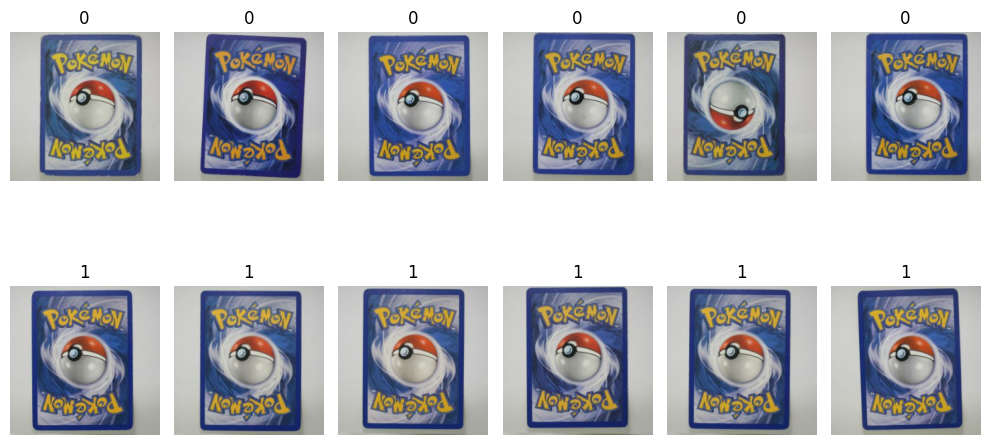

In [3]:
# We already figured out class distribution and class names.
#reconstruct the paths
imageCheck = df

imageCheck["path"] = imageCheck["id"].apply(
    lambda x: os.path.join(datasetPath, "train", f"{x}.JPG")
)

print(imageCheck.head())

missingImages = df[~df["path"].apply(os.path.exists)]
print(f"There are {len(missingImages)} images missing in the dataset")
print(missingImages.head())


def loadImagesToCheck(path):
    imageSize = (224, 224)
    imageLoaded = tf.image.resize(tf.image.decode_jpeg(tf.io.read_file(path), channels=3), imageSize)
    return tf.cast(imageLoaded, tf.uint8)

sampleImageCheck = df.groupby("label").sample(6, random_state=42)

plt.figure()
plt.figure(figsize=(10,6))

for i, row in enumerate(sampleImageCheck.itertuples()):
    image = loadImagesToCheck(row.path)
    plt.subplot(2, 6, i + 1)
    plt.imshow(image.numpy())
    plt.title(f"{row.label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Now we need to check if the images are consistent, uncorrupted, and had mean image per class calculated

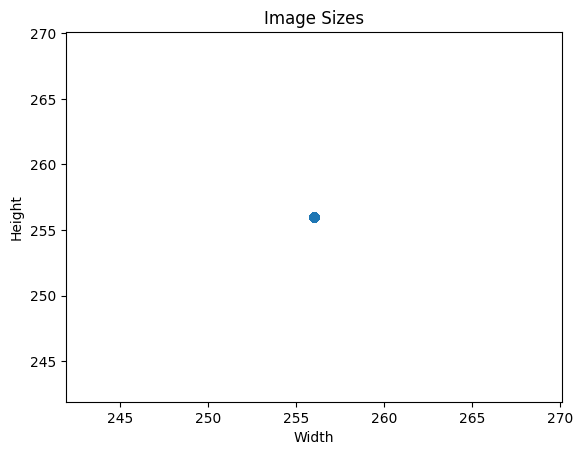

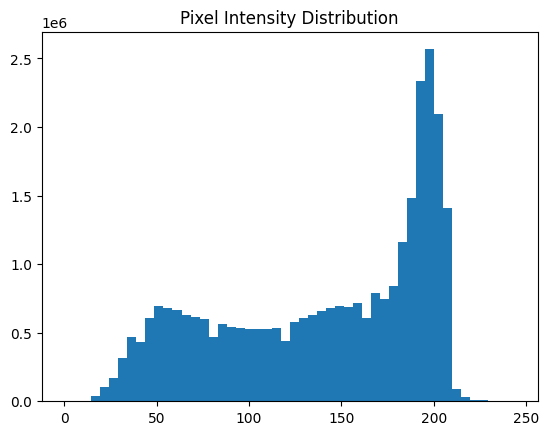

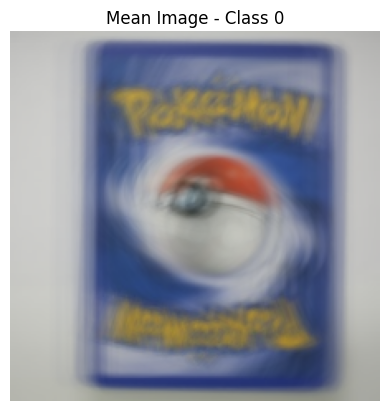

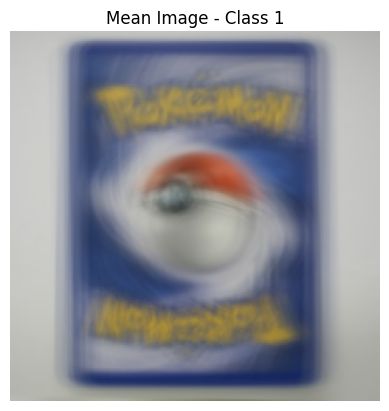

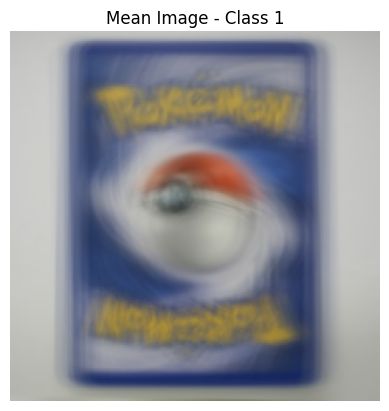

In [6]:
# check image size distributions
sizes = []
for path in imageCheck["path"]:
    try:
        with PIL.Image.open(path) as img:
            sizes.append(img.size)
    except: pass

widths, heights = zip(*sizes)

plt.scatter(widths, heights, alpha=0.3)
plt.title("Image Sizes")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

#check pixel intensity
def pixelDist(paths, n=200):
    pixels = []

    for p in paths[:n]:
        img = loadImagesToCheck(p).numpy()
        pixels.append(img.flatten())
    pixels = np.concatenate(pixels)

    plt.hist(pixels, bins=50)
    plt.title("Pixel Intensity Distribution")
    plt.show()

pixelDist(imageCheck["path"].values)

def meanImage(label):
    subset = imageCheck[imageCheck["label"] == label].sample(50, random_state=42)

    imgs = [loadImagesToCheck(p).numpy() for p in subset["path"]]

    imagesMean = np.mean(imgs, axis=0)

    plt.imshow(imagesMean.astype("uint8"))
    plt.title(f"Mean Image - Class {label}")
    plt.axis("off")
    plt.show(0)

#check for both labels
meanImage(0)
meanImage(1)

# We can assume test data is of same make.
# Preprocessing should not be necessary from the visual glance. 

Split the training set into training and validation sets. Train and tune hyperparameters.

Trial 16 Complete [00h 00m 37s]
val_accuracy: 0.9466666579246521

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 07m 04s
Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 352ms/step - accuracy: 0.5336 - loss: 1.3030 - val_accuracy: 0.6667 - val_loss: 0.5967
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7517 - loss: 0.5054 - val_accuracy: 0.8000 - val_loss: 0.4688
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7886 - loss: 0.4306 - val_accuracy: 0.7467 - val_loss: 0.4768
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8221 - loss: 0.4042 - val_accuracy: 0.7067 - val_loss: 0.5987
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8221 - loss: 0.3462 - val_accuracy: 0.8800 - val_loss: 0.3166
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8826 - loss: 0.2914 - val_accuracy: 0.9067 - val_loss: 0.2095
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9463 - loss: 0.1289 - val_accuracy: 0.9600 -

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,705,128 (37.02 MB)

 Trainable params: 3,235,042 (12.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,470,086 (24.68 MB)

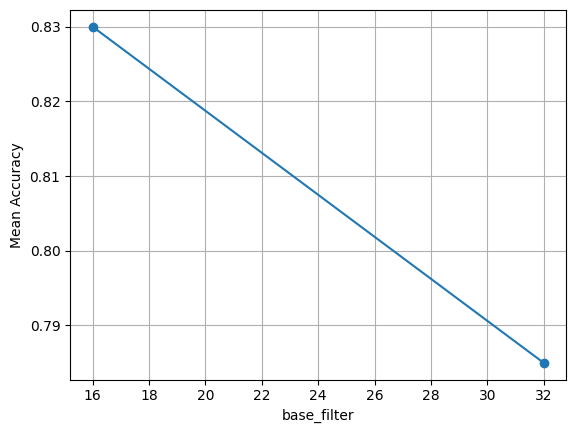

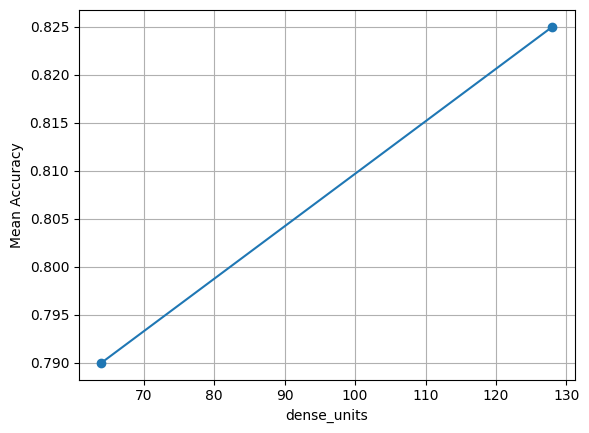

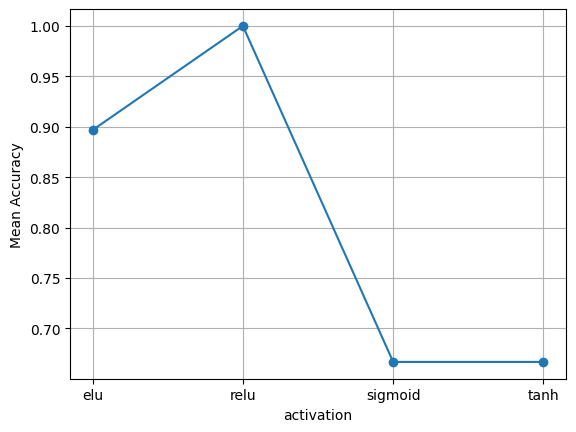

In [7]:
#shuffle dataset because the original dataset is ordered. We want to keep 
photoID_training, photoID_valid, classify_training, classify_valid = train_test_split(
    df["id"], df["label"],
    test_size= .2,
    stratify = df["label"],
    random_state=42
)

# 

def processThroughImages(imagesCollection, labels, stage):
    imagesArray = []
    labelToReturn= []
    # Images 1 - 298 in our dataset will be our training data. Rest will be testing
    for imageID, label in zip(imagesCollection, labels):
        imageToProcessFilePath = os.path.join(datasetPath, stage, f"{imageID}.JPG")
        
        if not os.path.exists(imageToProcessFilePath):
            print(f"Missing: {imageToProcessFilePath}")
            continue

        imageToProcess = keras.utils.img_to_array(keras.utils.load_img(imageToProcessFilePath, target_size=[224,224]))
        
        imagesArray.append(imageToProcess)
        labelToReturn.append(label)
    
    
    return np.array(imagesArray), np.array(labelToReturn)

trainingImagesArray, trainingClassifyArray = processThroughImages(photoID_training, classify_training, "train")
validationImagesArray, validationClassifyArray = processThroughImages(photoID_valid, classify_valid, "train")

#normalize for model's ease
trainingImagesArray /= 255.0
validationImagesArray /= 255.0

# hypertune parameters with model 1 and see what we can do
model1Tuner = kt.GridSearch(
    build_tensor_deep_model,
    objective="val_accuracy",
    max_trials=None,
    directory="fakeCardTensorflowLogs",
    project_name="pokemonFakeCardClassifierDeepModel"
)

model1Tuner.search(
    trainingImagesArray, trainingClassifyArray,
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

# display our results of our tuning here. 
def showHyperPlot(param: str, results, groupBy="mean_test_score"):
  toPlot = results.groupby(param)[groupBy].mean()
  plt.figure()
  plt.plot(toPlot.index, toPlot.values, marker="o")
  plt.xlabel(param)
  plt.ylabel("Mean Accuracy")
  plt.grid(True)
  plt.show()




# rebuild with best hyperparameters and get our final tuned model
model1 = model1Tuner.hypermodel.build(model1Tuner.get_best_hyperparameters(1)[0])

model1.fit(
    trainingImagesArray, trainingClassifyArray, 
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model1Results = pd.DataFrame([
    {**t.hyperparameters.values, "score": t.score} for t in model1Tuner.oracle.trials.values() if t.score is not None
])
print(model1Results.columns)
print(model1Results.head())


model1.summary()
showHyperPlot("base_filter", model1Results, "score")
showHyperPlot("dense_units", model1Results, "score")
showHyperPlot("activation", model1Results, "score")

Let's try creation a second model and see which one is more accurate. We're going to build a Tensorflow shallow learning model (even if it is not recommended for image processing and classification) and see if it could ever beat it.

Trial 8 Complete [00h 00m 16s]
val_accuracy: 0.6666666865348816

Best val_accuracy So Far: 0.9866666793823242
Total elapsed time: 00h 02m 04s
Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.5705 - loss: 31.7724 - val_accuracy: 0.8133 - val_loss: 2.8710
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5940 - loss: 12.1255 - val_accuracy: 0.7067 - val_loss: 4.6863
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7013 - loss: 6.1708 - val_accuracy: 0.8133 - val_loss: 3.2712
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7617 - loss: 3.5501 - val_accuracy: 0.8133 - val_loss: 2.4206
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8020 - loss: 1.8469 - val_accuracy: 0.8267 - val_loss: 0.8626
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7584 - loss: 1.3509 - val_accuracy: 0.8000 - val_loss: 0.6344
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7752 - loss: 1.0295 - val_ac

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     9,633,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,901,960 (110.25 MB)

 Trainable params: 9,633,986 (36.75 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,267,974 (73.50 MB)

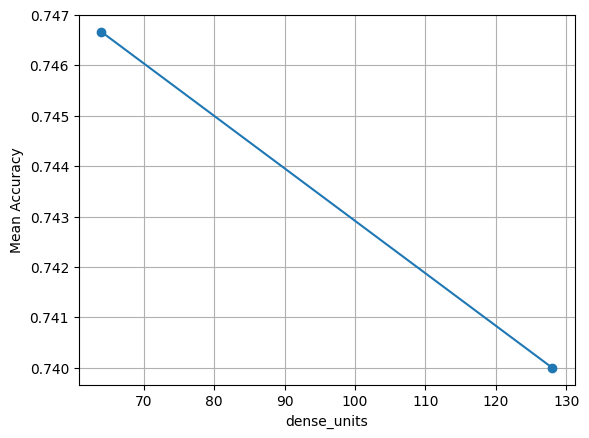

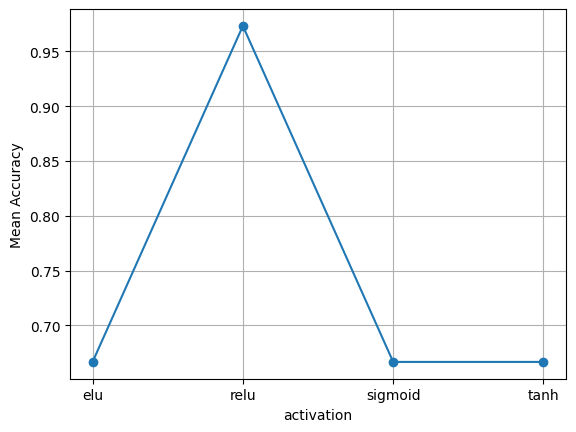

In [8]:
from sklearn.metrics import accuracy_score, classification_report

#Let's tune hyperparameters
def build_tensor_shallow_model(hp):
    dense_units = hp.Choice("dense_units", [64, 128]) # for feature classification 
    activeFunctions = hp.Choice("activation", ["relu", "sigmoid", "tanh", "elu"])
    model = keras.models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Flatten(),
        layers.Dense(dense_units, activation=activeFunctions),
        layers.Dense(2)
    ])
    model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    return model

model2Tuner = kt.RandomSearch(
    build_tensor_shallow_model,
    objective="val_accuracy",
    max_trials=50,
    directory="fakeCardTensorflowLogs",
    project_name="pokemonFakeCardClassifierShallowModel"
)

model2Tuner.search(
    trainingImagesArray, trainingClassifyArray,
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model2Results = pd.DataFrame([
    {**t.hyperparameters.values, "score": t.score} for t in model2Tuner.oracle.trials.values() if t.score is not None
])

model2 = model2Tuner.hypermodel.build(model2Tuner.get_best_hyperparameters(1)[0])

model2.fit(
    trainingImagesArray, trainingClassifyArray, 
    epochs = 30,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model2.summary()
showHyperPlot("dense_units", model2Results, "score")
showHyperPlot("activation", model2Results, "score")

Test it on the test data we have set, then compare the two models. Pick the best one from here and export as a backend api

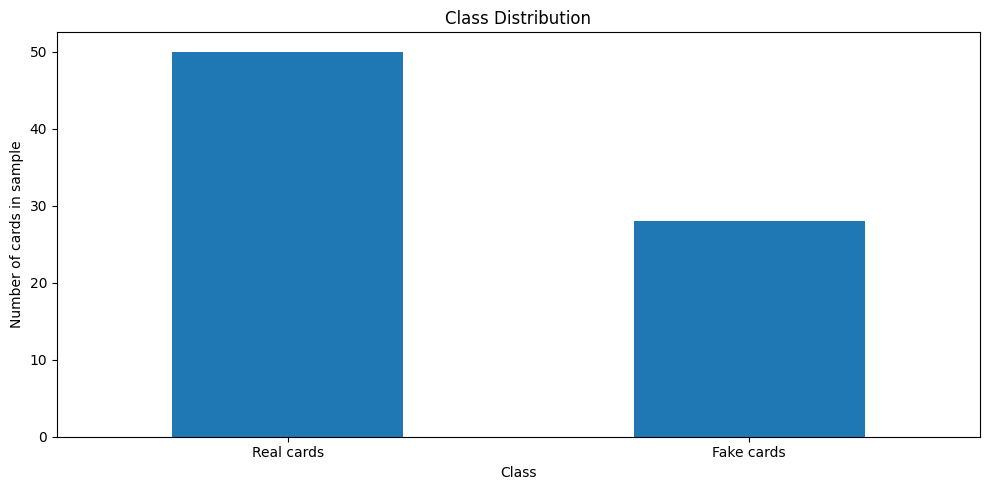

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 393ms/step
Model 1 accuracy: 0.9743589743589743
              precision    recall  f1-score   support

  Fake Cards       0.96      0.96      0.96        28
  Real Cards       0.98      0.98      0.98        50

    accuracy                           0.97        78
   macro avg       0.97      0.97      0.97        78
weighted avg       0.97      0.97      0.97        78

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step
Model 2 accuracy: 0.9743589743589743
              precision    recall  f1-score   support

  Fake Cards       1.00      0.93      0.96        28
  Real Cards       0.96      1.00      0.98        50

    accuracy                           0.97        78
   macro avg       0.98      0.96      0.97        78
weighted avg       0.98      0.97      0.97        78



In [ ]:
#prepare test set
testDF = pd.read_csv(f"{datasetPath}/test_labels.csv").sample(frac=1, random_state=42).reset_index(drop=True)
plt.figure(figsize=(10,5))
testDF["label"].map({0: "Fake cards", 1: "Real cards"}).value_counts().plot(kind="bar")
plt.title("Class Distribution For Test Cases.")
plt.xlabel("Class")
plt.ylabel("Number of cards in sample")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


testImagesArray, testClassifyArray = processThroughImages(testDF["id"], testDF["label"], "test")
# test model 1
testCheck1 = np.argmax(model1.predict(testImagesArray), axis=1)
print(f"Model 1 accuracy: {accuracy_score(testClassifyArray, testCheck1)}")
print(classification_report(testClassifyArray, testCheck1, target_names=["Fake Cards", "Real Cards"]))
# test model 2
testCheck2 = np.argmax(model2.predict(testImagesArray), axis=1)
print(f"Model 2 accuracy: {accuracy_score(testClassifyArray, testCheck2)}")
print(classification_report(testClassifyArray, testCheck2, target_names=["Fake Cards", "Real Cards"]))





Use this information to export and download the winning model. Because model 1 won in accuracy, we can save it here.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

model1.save('/content/drive/MyDrive/fakeCardCNN.keras')

Mounted at /content/drive
